## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../../data/raw/assessments.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [2]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (206, 6)

Number of rows: 206
Number of columns: 6

Column names:
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [3]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0


Last 5 rows:
    code_module code_presentation  id_assessment assessment_type   date  \
201         GGG             2014J          37443             CMA  229.0   
202         GGG             2014J          37435             TMA   61.0   
203         GGG             2014J          37436             TMA  124.0   
204         GGG             2014J          37437             TMA  173.0   
205         GGG             2014J          37444            Exam  229.0   

     weight  
201     0.0  
202     0.0  
203     0.

## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [4]:
print('Data types:')
print(df.dtypes)
print('\n' + '='*80 + '\n')
print('Data type summary:')
print(df.dtypes.value_counts())

Data types:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object


Data type summary:
str        3
float64    2
int64      1
Name: count, dtype: int64


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [5]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

Missing values:
      Missing_Count  Missing_Percentage
date             11            5.339806


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [6]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
code_module: 199 duplicates (96.60%)
code_presentation: 202 duplicates (98.06%)
assessment_type: 203 duplicates (98.54%)
date: 131 duplicates (63.59%)
weight: 182 duplicates (88.35%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [7]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
       id_assessment        date      weight
count     206.000000  195.000000  206.000000
mean    26473.975728  145.005128   20.873786
std     10098.625521   76.001119   30.384224
min      1752.000000   12.000000    0.000000
25%     15023.250000   71.000000    0.000000
50%     25364.500000  152.000000   12.500000
75%     34891.750000  222.000000   24.250000
max     40088.000000  261.000000  100.000000


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()[:5]}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:
  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE']
Length: 5, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str

assessment_type:
  Unique values: 3
  Sample values: <StringArray>
['TMA', 'Exam', 'CMA']
Length: 3, dtype: str



C:\Users\Dell\AppData\Local\Temp\ipykernel_28656\1950261300.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [9]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
FFF    52
BBB    42
DDD    35
GGG    30
CCC    20
EEE    15
AAA    12
Name: count, dtype: int64

Percentage distribution:
code_module
FFF    25.242718
BBB    20.388350
DDD    16.990291
GGG    14.563107
CCC     9.708738
EEE     7.281553
AAA     5.825243
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2014J    57
2014B    57
2013J    53
2013B    39
Name: count, dtype: int64

Percentage distribution:
code_presentation
2014J    27.669903
2014B    27.669903
2013J    25.728155
2013B    18.932039
Name: proportion, dtype: float64


Value counts for assessment_type:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

Percentage distribution:
assessment_type
TMA     51.456311
CMA     36.893204
Exam    11.650485
Name: proportion, dtype: float64




## 10. Basic Visualisations - Histograms for Numeric Columns

Visual representations help us understand the distribution of numeric features at a glance.


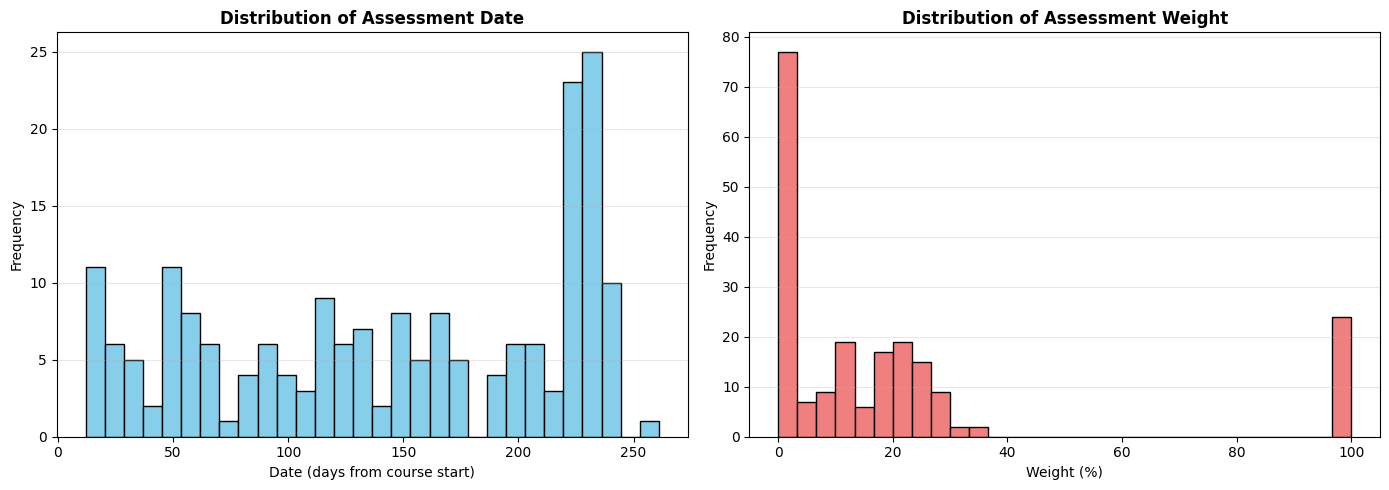

In [10]:
# Histograms for date and weight only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for date
axes[0].hist(df['date'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Assessment Date', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date (days from course start)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Histogram for weight
axes[1].hist(df['weight'].dropna(), bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Assessment Weight', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight (%)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

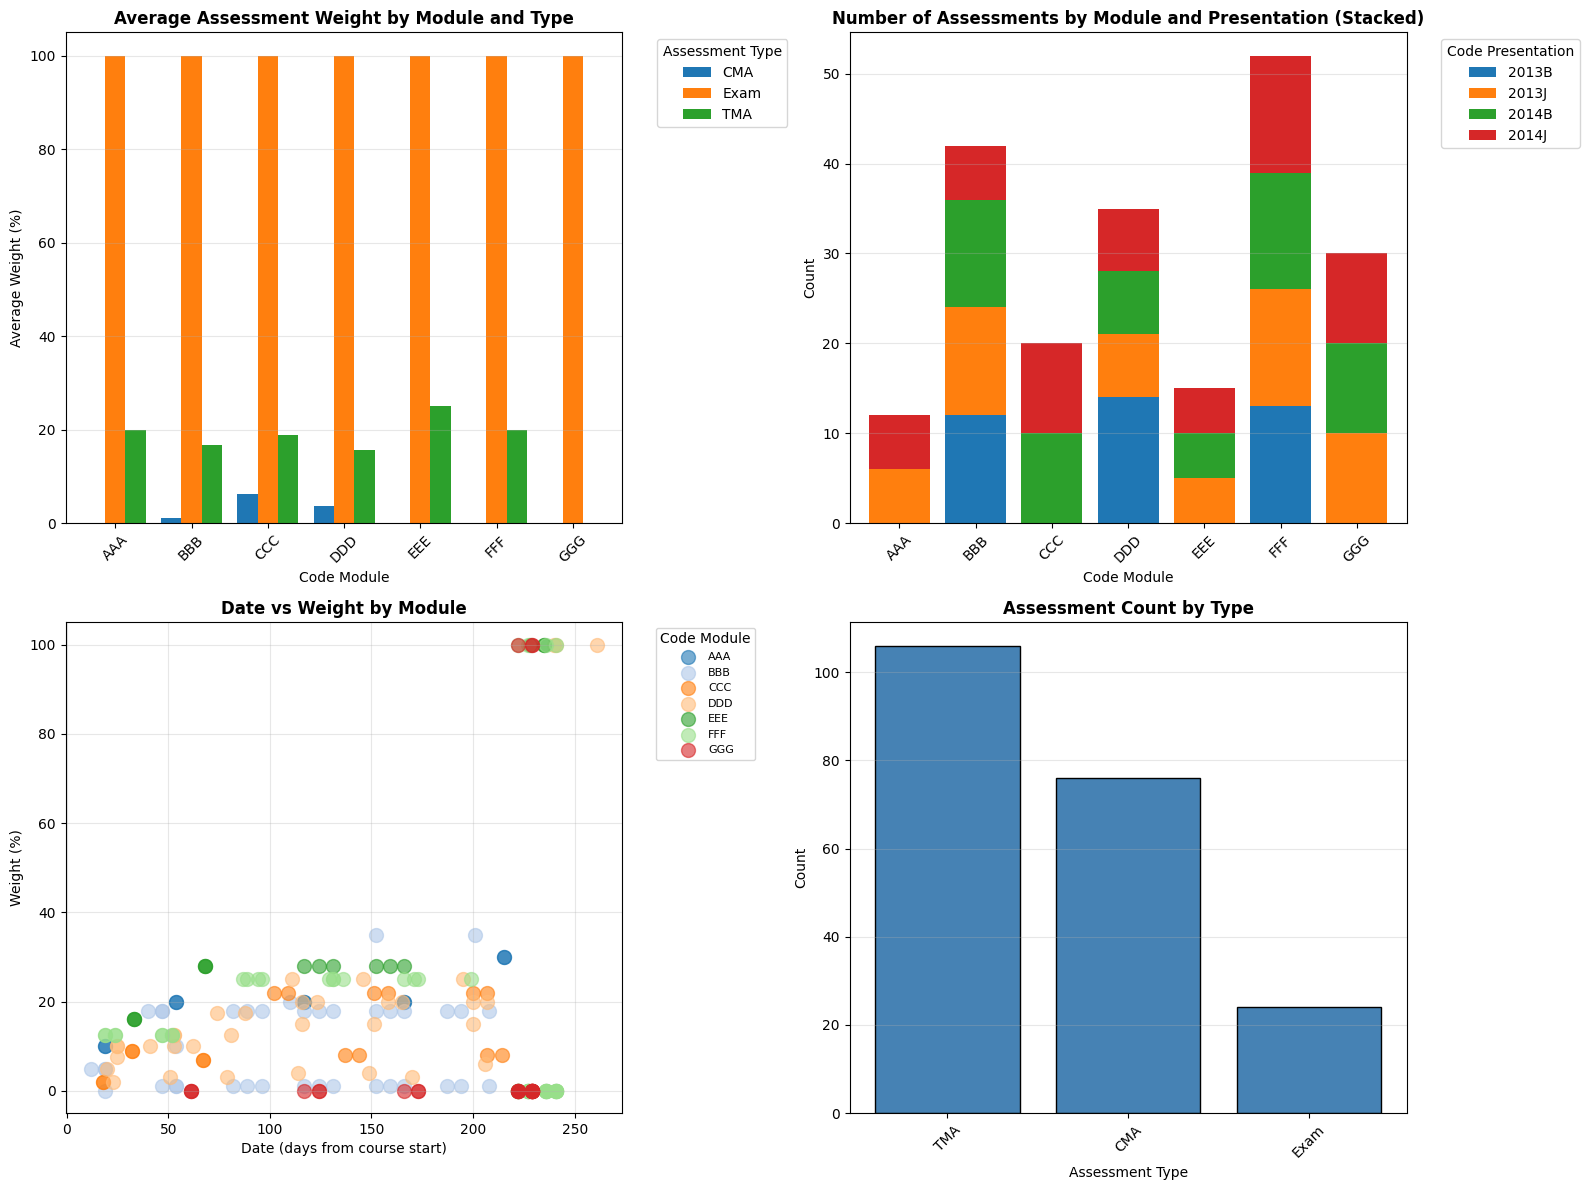

In [11]:
# Multi-dimensional analysis: Module, Presentation, Assessment Type, Date, and Weight
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average weight by module and assessment type
pivot_weight = df.pivot_table(values='weight', index='code_module', 
                               columns='assessment_type', aggfunc='mean')
pivot_weight.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Average Assessment Weight by Module and Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Code Module')
axes[0, 0].set_ylabel('Average Weight (%)')
axes[0, 0].legend(title='Assessment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Assessment count by module and presentation (STACKED)
pivot_count = df.pivot_table(values='id_assessment', index='code_module', 
                              columns='code_presentation', aggfunc='count')
pivot_count.plot(kind='bar', ax=axes[0, 1], width=0.8, stacked=True)
axes[0, 1].set_title('Number of Assessments by Module and Presentation (Stacked)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Code Module')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Code Presentation', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Scatter plot: Date vs Weight, colored by module
module_colors = {mod: plt.cm.tab20(i) for i, mod in enumerate(df['code_module'].unique())}
for module in df['code_module'].unique():
    module_data = df[df['code_module'] == module]
    axes[1, 0].scatter(module_data['date'], module_data['weight'], 
                      label=module, alpha=0.6, s=100, color=module_colors[module])

axes[1, 0].set_title('Date vs Weight by Module', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date (days from course start)')
axes[1, 0].set_ylabel('Weight (%)')
axes[1, 0].legend(title='Code Module', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Assessment count by assessment type
assessment_count = df['assessment_type'].value_counts()
axes[1, 1].bar(assessment_count.index, assessment_count.values, color='steelblue', edgecolor='black')
axes[1, 1].set_title('Assessment Count by Type', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Assessment Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Relationship between Assessment Type, Date, and Weight

Visualizing how assessment type relates to date and weight helps identify assessment scheduling and weighting patterns across different assessment types.


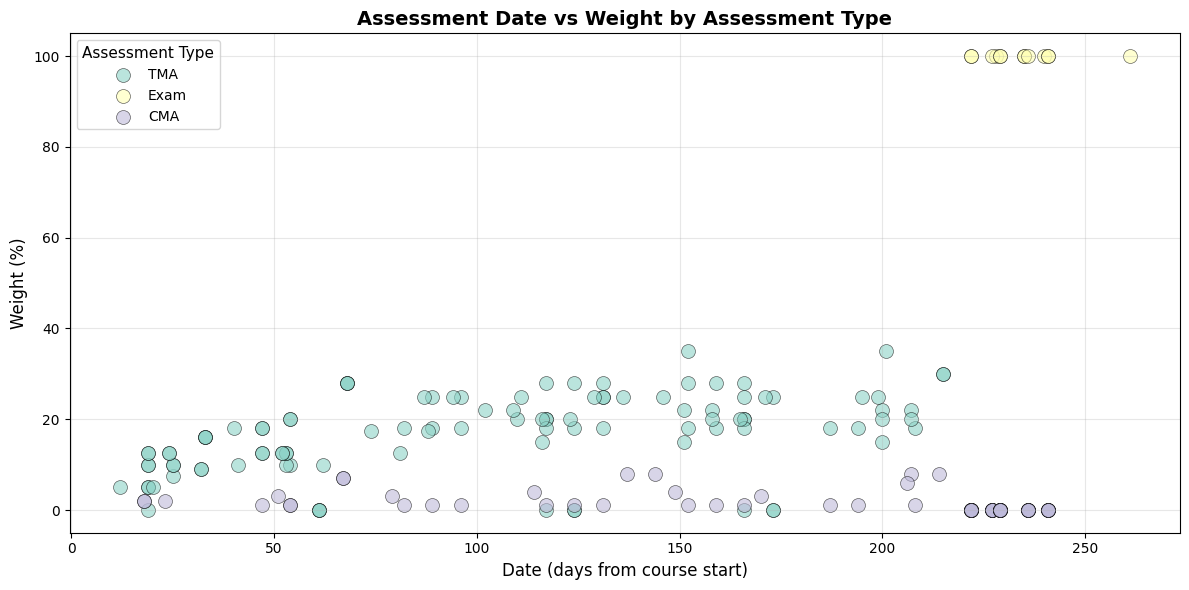

In [12]:
# Scatter plot: Assessment Type, Date, and Weight relationship
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot: Date vs Weight, colored by Assessment Type
assessment_types = df['assessment_type'].unique()
colors = plt.cm.Set3(range(len(assessment_types)))
color_map = {atype: colors[i] for i, atype in enumerate(assessment_types)}

for atype in assessment_types:
    mask = df['assessment_type'] == atype
    ax.scatter(df[mask]['date'], df[mask]['weight'], 
               label=atype, alpha=0.6, s=100, color=color_map[atype], edgecolors='black', linewidth=0.5)

ax.set_title('Assessment Date vs Weight by Assessment Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Date (days from course start)', fontsize=12)
ax.set_ylabel('Weight (%)', fontsize=12)
ax.legend(title='Assessment Type', fontsize=10, title_fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()